# DICOM Transcoding with nvImageCodec

This example demonstrates how to transcode DICOM series using nvImageCodec's utility functions:
1. **HTJ2K (High-Throughput JPEG 2000)** - Modern GPU-accelerated compression
2. **Multi-frame (Enhanced) DICOM** - Consolidate series into single file

HTJ2K offers lossless compression with ~2-3x size reduction and GPU-accelerated decoding, making it ideal for medical imaging archives and PACS systems.

**nvImageCodec provides utility functions** in `nvidia.nvimgcodec.tools.dicom` for common DICOM operations:
- `transcode_datasets_to_htj2k()` - Convert to HTJ2K compression
- `convert_to_enhanced_dicom()` - Create multi-frame DICOM files

## Load DICOM Series

First, let's load a DICOM series that we'll use for transcoding examples.

In [1]:
import os
import glob
import time
import tempfile
import pydicom
from pathlib import Path

# Path to DICOM series
resources_dir = os.getenv("PYNVIMGCODEC_EXAMPLES_RESOURCES_DIR", "../assets/images")
dicom_series_dir = os.path.join(resources_dir, "DICOM/MRI/Knee/DICOMS/STU00001/SER00001")

# Get all DICOM files in the series
dicom_files = sorted(glob.glob(os.path.join(dicom_series_dir, "*.dcm")))

print(f"Found {len(dicom_files)} DICOM files")
print(f"First file: {os.path.basename(dicom_files[0])}")
print(f"Last file: {os.path.basename(dicom_files[-1])}")

# Load the DICOM series
print(f"\nLoading {len(dicom_files)} DICOM files...")
start_time = time.time()
dicom_series = [pydicom.dcmread(f) for f in dicom_files]
load_time = time.time() - start_time

# Display basic information
first_ds = dicom_series[0]
print(f"✓ Loaded {len(dicom_series)} files in {load_time:.3f}s")
print(f"\nModality: {first_ds.Modality}")
print(f"Transfer Syntax: {first_ds.file_meta.TransferSyntaxUID.name}")
print(f"Image Size: {first_ds.Rows} x {first_ds.Columns}")
print(f"Series Length: {len(dicom_series)} slices")

Found 38 DICOM files
First file: IMG00001.dcm
Last file: IMG00038.dcm

Loading 38 DICOM files...
✓ Loaded 38 files in 0.029s

Modality: MR
Transfer Syntax: Implicit VR Little Endian
Image Size: 234 x 256
Series Length: 38 slices


## Transcode to HTJ2K with `transcode_datasets_to_htj2k()`

The original DICOM files use uncompressed pixel data, which is inefficient for storage. Let's transcode them to **HTJ2K (High-Throughput JPEG 2000)**:

### Benefits of HTJ2K:
- **Lossless compression** - No quality loss
- **Better compression** - ~2-3x smaller files
- **GPU-accelerated** - Fast decoding on GPU
- **DICOM standard** - Official transfer syntax

The `transcode_datasets_to_htj2k()` function handles all the complexity:
- Automatically detects source transfer syntax
- Batch processes for efficiency
- Preserves all DICOM metadata
- Returns transcoded datasets ready to save

In [2]:
from nvidia.nvimgcodec.tools.dicom.convert_htj2k import transcode_datasets_to_htj2k

# Transcode to HTJ2K
print("Transcoding to HTJ2K...")
print(f"Processing {len(dicom_series)} DICOM files\n")

start_time = time.time()
htj2k_datasets = transcode_datasets_to_htj2k(
    datasets=dicom_series,
    num_resolutions=6,          # Wavelet decomposition levels
    code_block_size=(64, 64),   # Code block size
    progression_order="RPCL",   # Resolution-Position-Component-Layer
    max_batch_size=256          # Batch size for GPU operations
)
transcode_time = time.time() - start_time

print(f"✓ Transcoded {len(htj2k_datasets)} files in {transcode_time:.3f}s")
print(f"  Average: {transcode_time/len(htj2k_datasets)*1000:.2f} ms/file")

# Verify the transcoding
print(f"\nOriginal Transfer Syntax: {dicom_series[0].file_meta.TransferSyntaxUID.name}")
print(f"New Transfer Syntax: {htj2k_datasets[0].file_meta.TransferSyntaxUID.name}")

Transcoding to HTJ2K...
Processing 38 DICOM files

✓ Transcoded 38 files in 0.166s
  Average: 4.36 ms/file

Original Transfer Syntax: High-Throughput JPEG 2000 with RPCL Options Image Compression (Lossless Only)
New Transfer Syntax: High-Throughput JPEG 2000 with RPCL Options Image Compression (Lossless Only)


### Compare File Sizes

Let's save the HTJ2K files temporarily to compare compression ratios. We use a context manager for automatic cleanup:

In [3]:
# Use TemporaryDirectory for automatic cleanup
with tempfile.TemporaryDirectory(prefix="dicom_htj2k_") as htj2k_dir:
    print(f"Saving HTJ2K files to temporary directory...")
    
    # Save transcoded files
    htj2k_files = []
    for i, ds in enumerate(htj2k_datasets):
        output_file = os.path.join(htj2k_dir, f"htj2k_{i:03d}.dcm")
        ds.save_as(output_file, write_like_original=False)
        htj2k_files.append(output_file)
    
    # Calculate compression statistics
    original_size = sum(os.path.getsize(f) for f in dicom_files)
    compressed_size = sum(os.path.getsize(f) for f in htj2k_files)
    compression_ratio = (1 - compressed_size / original_size) * 100
    
    print(f"\n{'='*70}")
    print("Compression Results")
    print('='*70)
    print(f"Original size:    {original_size / 1024:.1f} KB ({original_size / (1024**2):.2f} MB)")
    print(f"Compressed size:  {compressed_size / 1024:.1f} KB ({compressed_size / (1024**2):.2f} MB)")
    print(f"Space saved:      {compression_ratio:.1f}%")
    print(f"\n✓ Saved {len(htj2k_files)} HTJ2K files")


Saving HTJ2K files to temporary directory...

Compression Results
Original size:    4506.4 KB (4.40 MB)
Compressed size:  1881.8 KB (1.84 MB)
Space saved:      58.2%

✓ Saved 38 HTJ2K files


### Decode with pydicom Plugin

The HTJ2K datasets can be decoded using the pydicom plugin for GPU acceleration:

Transfer Syntax: High-Throughput JPEG 2000 with RPCL Options Image Compression (Lossless Only)
Pixel Array Shape: (234, 256)
Pixel Array dtype: uint16


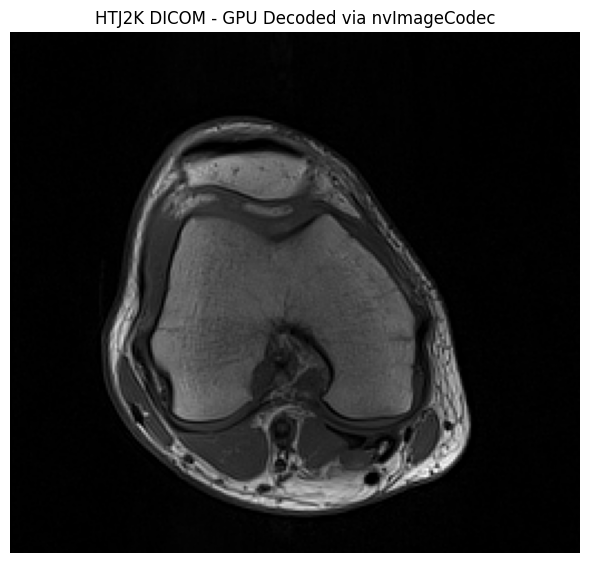


✓ GPU-accelerated decoding works seamlessly!


In [4]:
from nvidia.nvimgcodec.tools.dicom import pydicom_plugin
import matplotlib.pyplot as plt

# Register the plugin for GPU acceleration
pydicom_plugin.register()

# Decode an HTJ2K DICOM dataset (in memory, no file needed)
middle_slice = htj2k_datasets[len(htj2k_datasets) // 2]
print(f"Transfer Syntax: {middle_slice.file_meta.TransferSyntaxUID.name}")
print(f"Pixel Array Shape: {middle_slice.pixel_array.shape}")
print(f"Pixel Array dtype: {middle_slice.pixel_array.dtype}")

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(middle_slice.pixel_array, cmap="gray")
plt.title("HTJ2K DICOM - GPU Decoded via nvImageCodec")
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n✓ GPU-accelerated decoding works seamlessly!")

## Create Multi-Frame DICOM with `convert_to_enhanced_dicom()`

Instead of having 38 individual DICOM files, we can consolidate them into a **single multi-frame (Enhanced) DICOM** file.

### Benefits of Multi-Frame DICOM:
- **Single file** instead of hundreds of files
- **Better organization** with structured metadata
- **More efficient I/O** operations
- **Standards-compliant** (DICOM Part 3)

The `convert_to_enhanced_dicom()` function:
- Uses `highdicom` for standards-compliant conversion
- Supports CT, MR, and PT modalities
- **Can apply HTJ2K compression simultaneously** - no need to transcode first!
- Validates series consistency automatically

**Note:** Enhanced DICOM conversion requires certain standard attributes (like StudyTime, SeriesTime). If your datasets are missing these, we'll add them automatically before conversion.

In this example, we'll convert the **original uncompressed datasets** directly to multi-frame with HTJ2K compression in one step.

In [5]:
from nvidia.nvimgcodec.tools.dicom.convert_multiframe import convert_to_enhanced_dicom
from datetime import datetime

print("Converting to Enhanced Multi-Frame DICOM with HTJ2K compression...")
print(f"Input: {len(dicom_series)} single-frame uncompressed files")
print(f"Output: 1 multi-frame Enhanced DICOM file with HTJ2K compression\n")

start_time = time.time()
enhanced_datasets = convert_to_enhanced_dicom(
    series_datasets=[dicom_series],  # List of series (we have one series)
    transfer_syntax_uid="1.2.840.10008.1.2.4.202",  # HTJ2K with RPCL
    num_resolutions=6,
    code_block_size=(64, 64),
    progression_order="RPCL"
)
convert_time = time.time() - start_time

print(f"✓ Converted in {convert_time:.3f}s")

# Verify the result
assert len(enhanced_datasets) == 1, f"Expected 1 multi-frame dataset, got {len(enhanced_datasets)}"
print(f"\n✓ Successfully created 1 multi-frame dataset")
enhanced_ds = enhanced_datasets[0]
print(f"\nNumber of frames: {enhanced_ds.NumberOfFrames}")
print(f"Transfer Syntax: {enhanced_ds.file_meta.TransferSyntaxUID.name}")
print(f"SOP Class: {enhanced_ds.SOPClassUID.name}")

Converting to Enhanced Multi-Frame DICOM with HTJ2K compression...
Input: 38 single-frame uncompressed files
Output: 1 multi-frame Enhanced DICOM file with HTJ2K compression

✓ Converted in 0.827s

✓ Successfully created 1 multi-frame dataset

Number of frames: 38
Transfer Syntax: High-Throughput JPEG 2000 with RPCL Options Image Compression (Lossless Only)
SOP Class: Legacy Converted Enhanced MR Image Storage


### Save and Compare Multi-Frame DICOM

Let's save the multi-frame DICOM and compare with the original uncompressed series. 

This shows the combined benefit of:
1. **Multi-frame consolidation**: 38 files → 1 file
2. **HTJ2K compression**: ~2-3x size reduction

In [6]:
# Use TemporaryDirectory for automatic cleanup
with tempfile.TemporaryDirectory(prefix="dicom_multiframe_") as multiframe_dir:
    multiframe_file = os.path.join(multiframe_dir, "enhanced_multiframe.dcm")
    
    # Save the multi-frame DICOM
    enhanced_ds.save_as(multiframe_file, write_like_original=False)
    multiframe_size = os.path.getsize(multiframe_file)
    
    print(f"Saved multi-frame DICOM")
    print(f"Original series:      {len(dicom_files)} files, {sum(os.path.getsize(f) for f in dicom_files) / (1024**2):.2f} MB total")
    print(f"Enhanced multi-frame: 1 file, {multiframe_size / (1024**2):.2f} MB")
    print(f"\nCompression ratio: {(1 - multiframe_size / sum(os.path.getsize(f) for f in dicom_files)) * 100:.1f}% smaller")


Saved multi-frame DICOM
Original series:      38 files, 4.40 MB total
Enhanced multi-frame: 1 file, 1.80 MB

Compression ratio: 59.2% smaller


### Decode Multi-Frame DICOM

The pydicom plugin automatically handles multi-frame DICOM decoding:

Enhanced DICOM in memory
Transfer Syntax: High-Throughput JPEG 2000 with RPCL Options Image Compression (Lossless Only)
Number of frames: 38
Pixel array shape: (38, 234, 256)
✓ Decoded in 0.059s (1.55 ms/frame)

Pixel array shape: (38, 234, 256)
Pixel array dtype: uint16


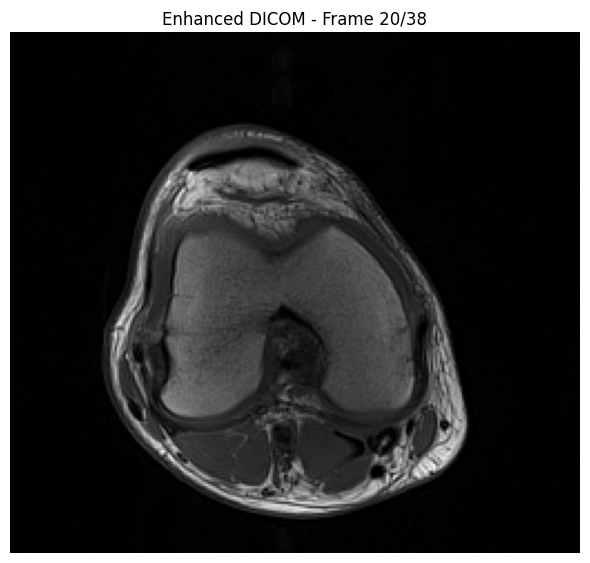

In [7]:
# Decode the enhanced DICOM (directly from memory, no file needed)
print(f"Enhanced DICOM in memory")
print(f"Transfer Syntax: {enhanced_ds.file_meta.TransferSyntaxUID.name}")

num_frames = enhanced_ds.NumberOfFrames
print(f"Number of frames: {num_frames}")

# Decode all frames (GPU-accelerated)
start_time = time.time()
pixel_array = enhanced_ds.pixel_array
print(f"Pixel array shape: {pixel_array.shape}")
decode_time = time.time() - start_time

print(f"✓ Decoded in {decode_time:.3f}s ({decode_time/num_frames*1000:.2f} ms/frame)")

print(f"\nPixel array shape: {pixel_array.shape}")
print(f"Pixel array dtype: {pixel_array.dtype}")

# Display middle slice
middle_frame = pixel_array.shape[0] // 2
plt.figure(figsize=(6, 6))
plt.imshow(pixel_array[middle_frame], cmap="gray")
plt.title(f"Enhanced DICOM - Frame {middle_frame+1}/{num_frames}")
plt.axis('off')
plt.tight_layout()
plt.show()

## Verify Data Integrity

Let's verify that the multi-frame data matches the original:

In [8]:
import numpy as np

# Load original data
print("Verifying data integrity...")
# Sort dicom_series by spatial position to match the order used by convert_to_enhanced_dicom.
# The converter sorts frames along the slice-stack normal before building the enhanced file,
# so we apply the same sort here to ensure frame-by-frame comparison is valid.
def _spatial_sort_key(ds):
    import numpy as _np
    if hasattr(ds, 'ImagePositionPatient') and hasattr(ds, 'ImageOrientationPatient'):
        iop = _np.array(list(ds.ImageOrientationPatient), dtype=float).reshape(2, 3)
        normal = _np.cross(iop[0], iop[1])
        return float(_np.dot(_np.array(list(ds.ImagePositionPatient), dtype=float), normal))
    return float(getattr(ds, 'InstanceNumber', 0))

sorted_series = sorted(dicom_series, key=_spatial_sort_key)
original_pixels = np.stack([ds.pixel_array for ds in sorted_series], axis=0)

# Get enhanced dataset pixels
enhanced_pixels = enhanced_ds.pixel_array

print(f"\nOriginal shape:  {original_pixels.shape}")
print(f"Enhanced shape:  {enhanced_pixels.shape}")

assert enhanced_pixels.shape == original_pixels.shape, f"\n⚠ Shape mismatch - enhanced data has different dimensions"
# Check if arrays are equal
assert np.array_equal(original_pixels, enhanced_pixels), f"\n⚠ Enhanced data is not identical to original."

Verifying data integrity...

Original shape:  (38, 234, 256)
Enhanced shape:  (38, 234, 256)
